[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/user/repo/blob/main/notebook.ipynb)

# Lecture 02: Review
- Data description
- Distribtions
- Probabilities

Acknowledgement: thanks Prof. Michael Tippett from APAM provide ENSO example

In [11]:
### 左边的【】如果没显示数字，意味着这个单元格没有被运行，有数字说明运行，数字代表执行顺序
### Load modules/functions 下面开始加载模块和函数
###先把文件管理、数值计算、气候多维数据处理、画图、统计分析和图片显示这些工具全部准备好，同时让之后生成的图直接、高清地显示在 Notebook 里。
import os #Operating System，它主要帮 Python 和电脑操作系统互动 os.getcwd() 可以查看我现在在哪个文件夹 os.listdir() 可以查看文件夹里有哪些文件
import numpy as np ### Numerical Python，专门处理数字和数组
import xarray as xr #xarray 是一个专门处理多维科学数据的包，比如温度可能是时间 × 纬度 × 经度

from matplotlib import pyplot as plt
from scipy import stats
import matplotlib.patches as mpatches

from IPython.display import Image
from matplotlib import image


%config InlineBackend.figure_format = 'retina'
%matplotlib inline

We are are going to use NOAA ERSSTv5

- Extended Reconstructed Sea Surface Temperature Version 5

- Monthly data going back to January 1854
https://psl.noaa.gov/data/gridded/data.noaa.ersst.v5.html

In [ ]:
# where you want the SST data file to go
dest = './ERSSTv5.sst.mnmean.nc'
url  = 'https://downloads.psl.noaa.gov/Datasets/noaa.ersst.v5/sst.mnmean.nc'

# large data, so we check if it has been downloaded
if os.path.exists(dest):
    !curl -L -R -z "{dest}" -o "{dest}" --fail "{url}"  ## only download if the remote file is newer...
else:
    !curl -L -R -o "{dest}" --fail "{url}"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0


## Describing the data

Let's look at data

In [ ]:
dest = './ERSSTv5.sst.mnmean.nc'
ds_ersstv5 = xr.open_dataset(dest)
### Check data
ds_ersstv5

<xarray.Dataset> Size: 133MB
Dimensions:    (time: 2072, nbnds: 2, lat: 89, lon: 180)
Coordinates:
  * time       (time) datetime64[ns] 17kB 1854-01-01 1854-02-01 ... 2026-08-01
  * lat        (lat) float32 356B 88.0 86.0 84.0 82.0 ... -84.0 -86.0 -88.0
  * lon        (lon) float32 720B 0.0 2.0 4.0 6.0 ... 352.0 354.0 356.0 358.0
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 33kB ...
    sst        (time, lat, lon) float32 133MB ...
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    creator_url_original:      https://www.ncei.noaa.gov
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2026-09-03

In [ ]:
## Name the variables using conventional name
ds_ersstv5 = ds_ersstv5.rename({'lat': 'latitude', 'lon': 'longitude'})
ds_ersstv5.attrs['short_name'] = 'ERSSTv5'
ds_ersstv5

<xarray.Dataset> Size: 133MB
Dimensions:    (time: 2072, nbnds: 2, latitude: 89, longitude: 180)
Coordinates:
  * time       (time) datetime64[ns] 17kB 1854-01-01 1854-02-01 ... 2026-08-01
  * latitude   (latitude) float32 356B 88.0 86.0 84.0 82.0 ... -84.0 -86.0 -88.0
  * longitude  (longitude) float32 720B 0.0 2.0 4.0 6.0 ... 354.0 356.0 358.0
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 33kB ...
    sst        (time, latitude, longitude) float32 133MB ...
Attributes: (12/38)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2026-09-03
    short_name:                ERSSTv5

Plot data and save images

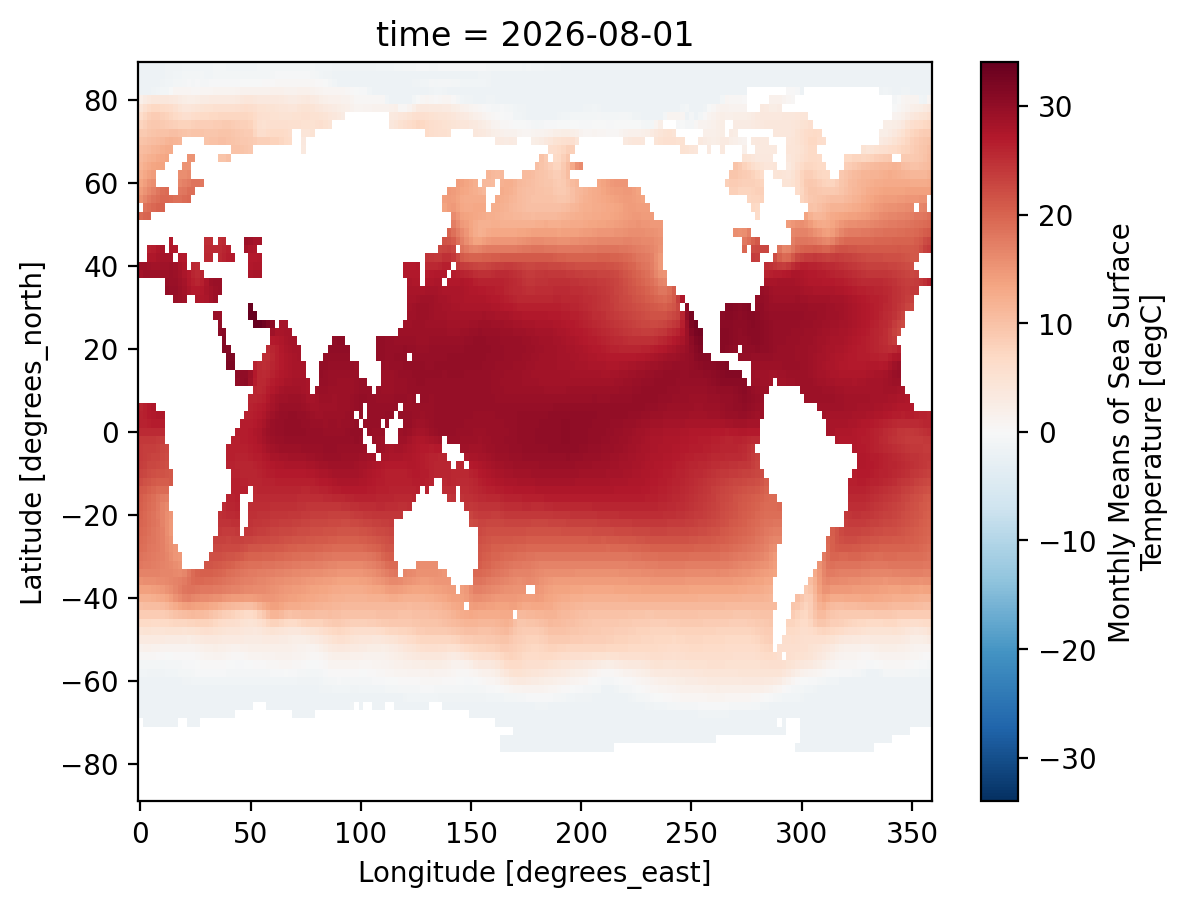

In [ ]:
### 2D map of SST for July
sst = ds_ersstv5['sst']
#sst.isel(time=-1).plot()
sst.sel(time='2026-08-01').plot()
plt.savefig('August_SST.png',dpi=200)
plt.show()

- how warm it is?
- look at anomaly

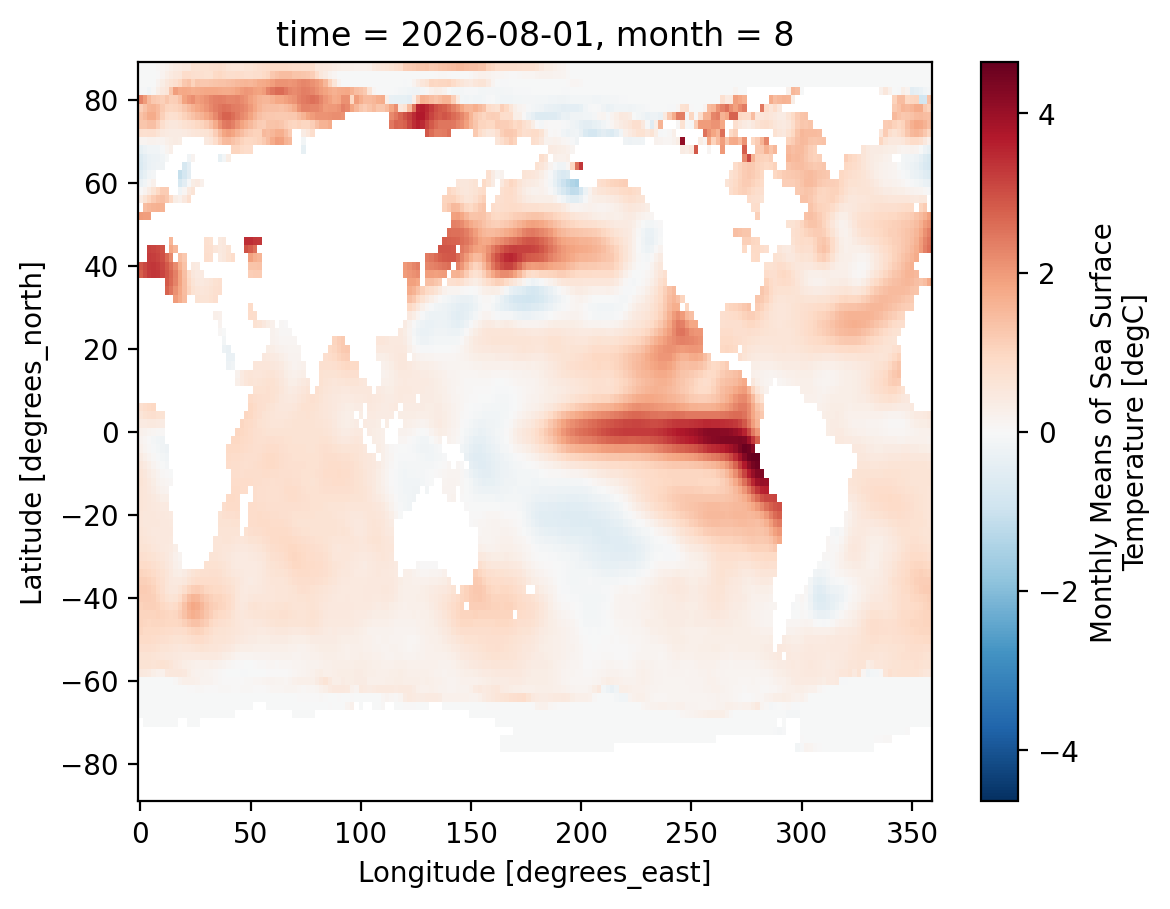

In [ ]:
### NOAA's definition of climatology -- past 30 years
monthly_mean_sst = sst.sel(time=slice('1991', '2020')).groupby('time.month').mean('time')
ssta = sst.groupby('time.month') - monthly_mean_sst
ssta.isel(time=-1).plot()

- waht do you see

- is this a really strong ENSO?  comparable to 1997/8 ones?

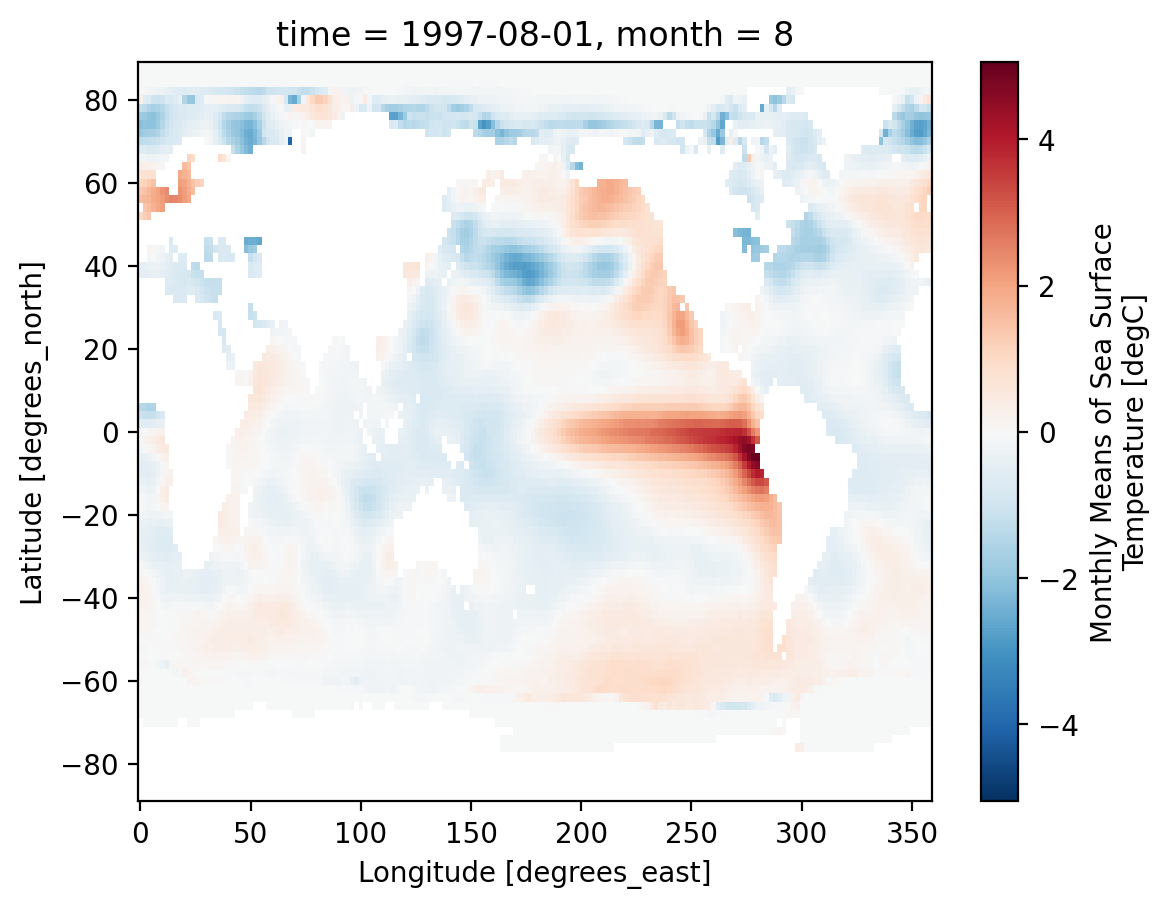

In [ ]:
ssta.sel(time='1997-08-01').plot()

- ENSO is defined using Nino3.4 box 5N-5S, 170W-120W  (i.e., 190E-240E)
### Function
- we can write a function to do it

In [ ]:
def n34_average(x):
    """
    Calculate x (temperature) over Niño 3.4 region"
    Note that grid cells near the equator represent more actual surface area than cells near the poles
    (since longitude lines converge toward the poles),
    so a simple unweighted mean would bias the average toward high latitudes. Weighting by cos(latitude) corrects for this.
    """

    x = x.sortby("latitude")
    weights = np.cos(np.deg2rad(x.latitude))
    y = x.sel(longitude=slice(190, 240)).sel(latitude=slice(-5, 5)).weighted(weights).mean(['longitude', 'latitude'])
    y.attrs = x.attrs.copy()
    return y

- n34 data

In [ ]:
n34 = n34_average(sst) ###把全球 SST 数据丢进刚才写好的 n34_average() 函数 → 算出 Niño 3.4 区域平均海温

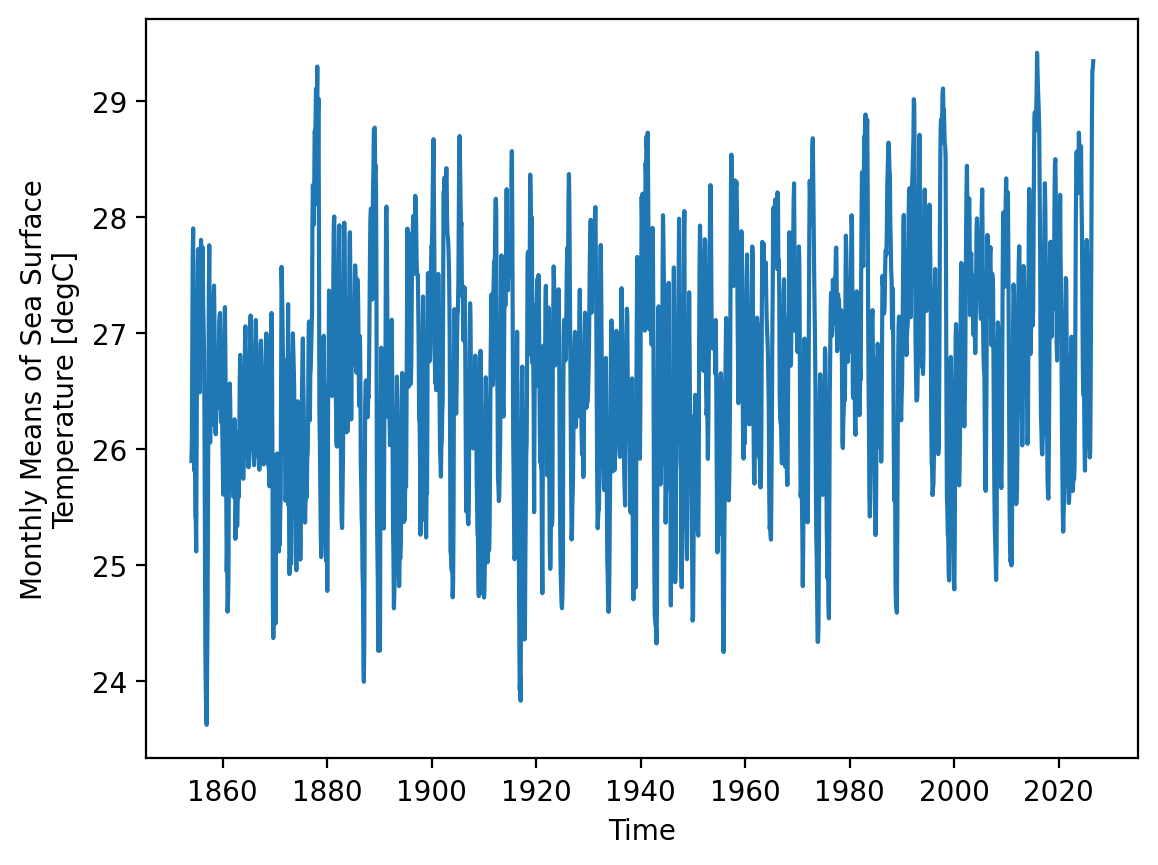

In [ ]:
n34.plot()

### Histogram

2026-07 n34: <xarray.DataArray 'sst' (time: 1)> Size: 4B
array([29.277988], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8B 2026-07-01
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]


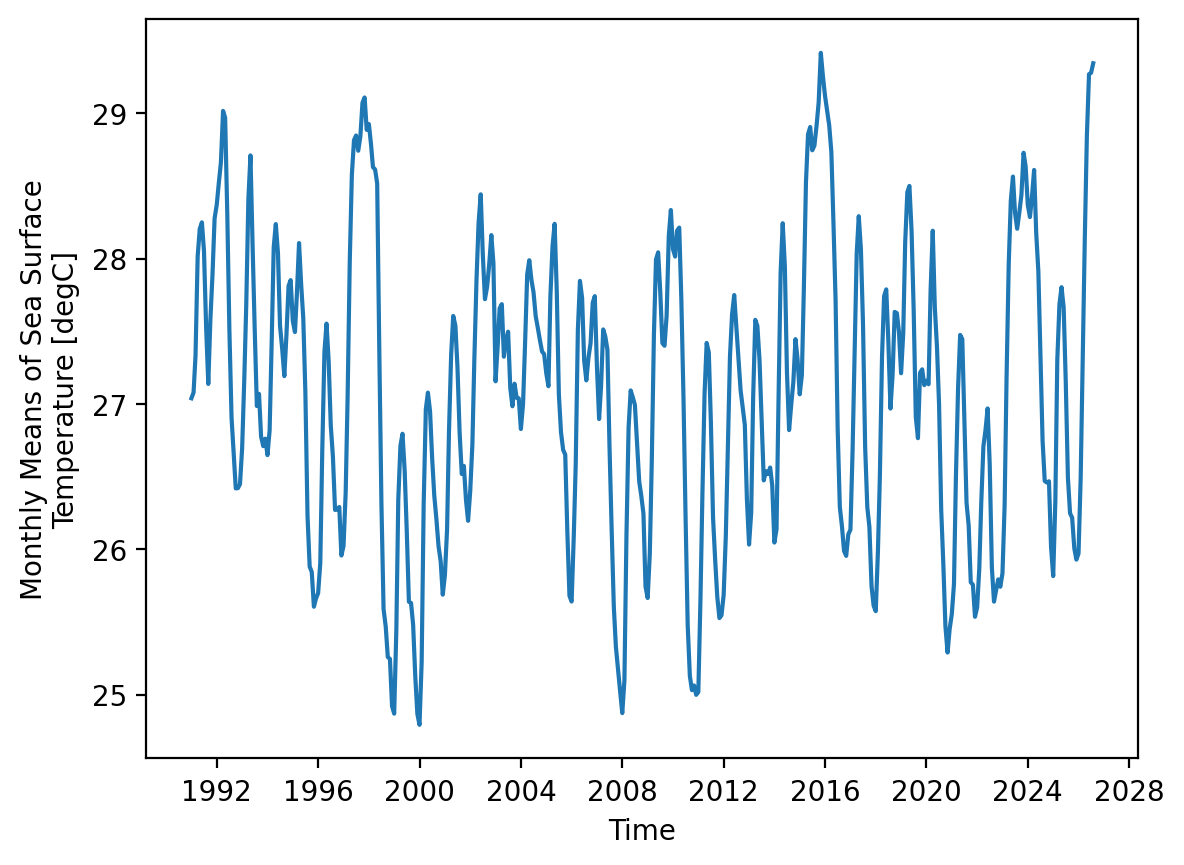

In [ ]:
n34.sel(time=slice('1991', '2026')).plot() #从整条 Niño 3.4 时间序列里，只截取 1991–2026，把它画出来。
ax = plt.gca() #gca()是get current axes：把刚刚画出来的那张图的坐标轴对象拿出来，把它叫ax
#ax.set_title('Niño 3.4 SST')这样可以改刚才图的标题


# grab the value at July 2026 获取2026年7月数值
target_date = '2026-07' # 创建一个变量，2026-07
val = n34.sel(time=target_date) #取出 2026 年 7 月的数据
print('2026-07 n34:', val) # or val.value #把结果打印出来
plt.savefig('n34.png',dpi =200)

In [ ]:
val

<xarray.DataArray 'sst' (time: 1)> Size: 4B
array([29.277988], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 8B 2026-07-01
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]

### Sample Mean
$$\hat{\mu} = \frac{1}{n}\sum_{i=1}^{n} x_i$$

In [ ]:
n34_x = n34.sel(time=slice('1991', '2026'))
np.mean(n34_x)

<xarray.DataArray 'sst' ()> Size: 8B
array(27.07761192)
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]

### Sample Standard Deviation

$$\hat{\sigma} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (x_i - \hat{\mu})^2}$$

In [ ]:
np.std(n34_x)

<xarray.DataArray 'sst' ()> Size: 8B
array(1.02024662)
Attributes:
    long_name:     Monthly Means of Sea Surface Temperature
    units:         degC
    var_desc:      Sea Surface Temperature
    level_desc:    Surface
    statistic:     Mean
    dataset:       NOAA Extended Reconstructed SST V5
    parent_stat:   Individual Values
    actual_range:  [-1.8     42.32636]
    valid_range:   [-1.8 45. ]

### Sample Skewness
$$\hat{\gamma} = \frac{\frac{1}{n}\sum_{i=1}^{n} (x_i - \hat{\mu})^3}{\hat{\sigma}^3}$$

In [ ]:
stats.skew(n34_x)

np.float32(-0.019268015)

### Sample Kurtosis
$$\hat{k} = \frac{\frac{1}{n}\sum_{i=1}^{n} (x_i - \hat{\mu})^4}{\hat{\sigma}^4}$$

In [ ]:
stats.kurtosis(n34_x)

np.float32(-0.6430237)

### Quantiles

In [ ]:
np.percentile(n34_x, [5, 95])

array([25.46796303, 28.80452023])

-- back to lecture--

Let's calculate n34 anomaly, and give me the all 5 moments and quantile of 5th and 95th value. Also, see where the anomalous n34 for July locats

### Distribution

### Normal Distribuiton
$$p(x) = \frac{1}{\hat{\sigma}\sqrt{2\pi}} \exp\left(-\frac{(x-\hat{\mu})^2}{2\hat{\sigma}^2}\right)$$

Now let's use stats function to fit the data

- Q-Q plot:
stats.probplot https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.probplot.html

### Gamma
$$p(x) = \frac{1}{\Gamma(k)\,\theta^{k}} x^{k-1} e^{-x/\theta}, \quad x > 0$$

- let's clean the data

In [ ]:
import pandas as pd


In [ ]:
df = pd.read_csv('/content/NYC_data_clean.csv')  # or whatever it turns out to be

In [ ]:
df

,DATE,PRCP
0,1999-01-01,0.00
1,1999-01-02,0.00
2,1999-01-03,2.42
3,1999-01-04,0.00
4,1999-01-05,0.00
...,...,...
10073,2026-07-31,0.03
10074,2026-08-01,0.00
10075,2026-08-02,0.07
10076,2026-08-03,1.93


In [ ]:
df['DATE'] = pd.to_datetime(df['DATE'])
df['PRCP'] = pd.to_numeric(df['PRCP'], errors='coerce')
df = df.dropna(subset=['PRCP'])

# --- Isolate wet days (gamma is undefined at 0, and dry days dominate) ---
wet = df.loc[df['PRCP'] > 0, 'PRCP'].values
frac_wet = len(wet) / len(df)

print(f"Wet days: {len(wet)} ({frac_wet*100:.1f}% of days)")

Wet days: 3481 (34.5% of days)


- fit and plot Gamma\distribution

In [ ]:
shape, loc, scale = stats.gamma.fit(wet, floc=0)
print(f"Gamma fit: shape (k) = {shape:.4f}, scale (theta) = {scale:.4f}")
print(f"Implied mean = {shape*scale:.4f}, variance = {shape*scale**2:.4f}")

Gamma fit: shape (k) = 0.6491, scale (theta) = 0.6160
Implied mean = 0.3998, variance = 0.2463


### probability of exceedance

In [ ]:
# --- Aggregate to monthly total precipitation ---
monthly = df.set_index('DATE')['PRCP'].resample('MS').sum()
monthly = monthly[monthly.index < monthly.index.max()]  # drop possibly incomplete last month

In [ ]:
july = monthly[monthly.index.month == 7].sort_values()
val_2026 = july[july.index.year == 2026].values[0]

# --- Fit Gamma distribution ---
shape, loc, scale = stats.gamma.fit(july.values, floc=0)

# --- Fitted (gamma) exceedance probability ---
fit_p = 1 - stats.gamma.cdf(val_2026, shape, loc, scale)
fit_return_period = 1 / fit_p
print (fit_return_period)


2.358892087804351
